# Week 1 — Numerical benchmarks for the Ornstein–Uhlenbeck Fokker–Planck equation

## Aim

This notebook validates the numerical data-generation methods used in the
later equation-discovery experiments.

The Ornstein–Uhlenbeck density is generated in three ways:

1. from the analytical Gaussian solution;
2. from a finite-difference discretisation of the Fokker–Planck equation;
3. from Euler–Maruyama trajectories followed by histogram estimation.

The exact density is used to assess discretisation error, domain truncation,
Monte Carlo sampling error, and histogram error before sparse equation
identification is attempted.

The Fokker–Planck equation describes the evolution of a probability density
under deterministic drift and stochastic diffusion. If $\rho(x,t)$ denotes
the probability density of a particle moving in a potential $V(x)$, then a
standard form of the equation is

$$
\partial_t\rho
=
\partial_x\left(
\partial_x\rho+\rho\,\partial_xV
\right).
$$

The diffusion term spreads probability mass, while the drift term transports
the density towards regions of lower potential.

## Stochastic Differential Equations(SDEs)

$$dX(t)=b(X(t))dt+\sigma (X(t))dW(t), \qquad  t \geq 0$$
$$X(0)=X_0,\tag{1}$$
are characterized by a right-hand side depending on two terms:
  - the function $b:\mathbb{R}^d \to \mathbb{R}^d,$ well known as $\mathit{drift}$ of the problem, that is the coefficients of its deterministic part;
  - the function $\sigma:\mathbb{R}^d \to \mathbb{R}^{d\times m},$ denoted in the literature as $\mathit{diffusion}$ of the problem, that is the coeeficient of its stochastic part.
The term $W(t)$ is  a $m$-dimensional standard Wiener process and, due to its nowhere differentiability, the representation given above is a shorthand notation for its integral counterpart
$$X(t)=X(0)+\int_0^t b(X(s))ds+ \int_0^t \sigma(X(s))dW(s) $$


## Markov Generator

$\mathcal{L} (\phi) = b \phi' + \frac{1}{2} \sigma^2 \phi'' \Leftrightarrow  \partial_t \rho = \mathcal{L}^* (\rho) = - \partial_x (b\rho) +\frac{1}{2}\partial_{xx}(\sigma^2 \rho) $

## Ornstein–Uhlenbeck Process

$$ dX_t = -\kappa X_t dt + \sqrt{2D} dW_t \Leftrightarrow   \partial_t \rho = \kappa \partial_x(x\rho)+D\rho_{xx}$$
$$ J = -\kappa x\rho - D \rho_{x}, \qquad \rho_t=-\partial_x J$$
which subjects to the zero-flux boundary conditions:
$$J(x_L,t)=J(x_R,t)=0$$
and inital data 
$$\rho(x,0) = \frac{1}{\sqrt{2\pi} s_0} \exp(-\frac{1}{2} (\frac{x-m_0}{s_0})^2)  $$
with $m_0=-2$ and $s_0=0.5$.

In [1]:
#====================================
# parameters
#====================================
k = 1.0
D = 1.0

x_L = -5.0
x_R = 5.0
m0 = -2.0
s0 = 0.5
T=3.0


### Finite Difference

In [2]:
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import ndtr
from IPython.display import display

$x_i = x_L+ih, \quad \rho_i(t)=\rho(x_i,t).$

In [3]:
# ============================================================
# Import the reusable finite-difference solver
# ============================================================

import ou_fd

# This is useful after editing ou_fd.py while the Jupyter kernel is running.
importlib.reload(ou_fd)

solve_ou_fd = ou_fd.solve_ou_fd


In [4]:
ou_parameters = {
    "k": k,
    "D": D,
    "x_L": x_L,
    "x_R": x_R,
    "m0": m0,
    "s0": s0,
    "T": T,
}


In [5]:
# The finite-difference implementation is contained in ou_fd.py.
# Do not redefine solve_ou_fd in this notebook, because doing so would
# overwrite the function imported from the external module.

In [6]:
def ou_mean_variance(t, k, D, m0, s0):

    mean = m0 * np.exp(-k * t)

    variance = (
        s0**2 * np.exp(-2 * k * t)
        + D / k * (1.0 - np.exp(-2 * k * t))
    )

    return mean, variance


def exact_mass_inside(t, x_L, x_R, k, D, m0, s0):

    mean, variance = ou_mean_variance(t, k, D, m0, s0)
    std = np.sqrt(variance)

    z_left = (x_L - mean) / std
    z_right = (x_R - mean) / std

    return ndtr(z_right) - ndtr(z_left)


def exact_mass_outside(t, x_L, x_R, k, D, m0, s0):

    mean, variance = ou_mean_variance(t, k, D, m0, s0)
    std = np.sqrt(variance)

    z_left = (x_L - mean) / std
    z_right = (x_R - mean) / std

    left_tail = ndtr(z_left)
    right_tail = ndtr(-z_right)

    return left_tail + right_tail

In [7]:
# exact solution
def exact_ou_density(x, t, k, D, m0, s0):
    mean = m0 * np.exp(-k * t)

    variance = (s0**2 * np.exp(-2 * k * t)+ D / k * (1 - np.exp(-2 * k * t)))

    return (np.exp(-(x - mean)**2 / (2 * variance))/ np.sqrt(2 * np.pi * variance))

### EOC against the whole-line exact solution restricted to $[x_L, x_R]$

In [8]:
#spatial size
Nx_values = [50, 100, 200, 400]
Nt_values = [6000,24000,96000,384000]

results = []

for i in range(len(Nt_values)):
    Nx = Nx_values[i]
    Nt = Nt_values[i]
    
    solution = solve_ou_fd(
        Nx,
        Nt,
        **ou_parameters
)
    
    x = solution["x"]
    rho_num = solution["rho_final"]
    dx = solution["dx"]
    dt = solution["dt"]

    rho_exact = exact_ou_density(x,T,k,D,m0,s0)
    
    error = rho_num - rho_exact
    
    E1 = dx * np.sum(np.abs(error))
    E2 = np.sqrt(dx) * np.linalg.norm(error, 2)
    Emax = np.max(np.abs(error))
    
    
    results.append({
        "Nx": Nx,
        "Nt": Nt,
        "dx": dx,
        "dt": dt,
        "L1": E1,
        "L2": E2,
        "Linf": Emax,
    })

In [9]:
for i in range(len(results)):

    if i == 0:
        results[i]["EOC_L1"] = np.nan
        results[i]["EOC_L2"] = np.nan
        results[i]["EOC_Linf"] = np.nan

    else:
        old = results[i - 1]
        new = results[i]

        denominator = np.log(
            old["dx"] / new["dx"]
        )

        results[i]["EOC_L1"] = (
            np.log(old["L1"] / new["L1"])
            / denominator
        )

        results[i]["EOC_L2"] = (
            np.log(old["L2"] / new["L2"])
            / denominator
        )

        results[i]["EOC_Linf"] = (
            np.log(old["Linf"] / new["Linf"])
            / denominator
        )

In [10]:
print(
    f"{'Nx':>6} "
    f"{'Nt':>8} "
    f"{'dx':>12} "
    f"{'dt':>12} "
    f"{'L1 error':>14} "
    f"{'EOC L1':>10} "
    f"{'Linf error':>14} "
    f"{'EOC Linf':>12}"
    f"{'L2 error':>14} "
    f"{'EOC L2':>12}"
)

for result in results:
    print(
        f"{result['Nx']:6d} "
        f"{result['Nt']:8d} "
        f"{result['dx']:12.4e} "
        f"{result['dt']:12.4e} "
        f"{result['L1']:14.6e} "
        f"{result['EOC_L1']:10.4f} "
        f"{result['Linf']:14.6e} "
        f"{result['EOC_Linf']:12.4f}"
        f"{result['L2']:14.6e} "
        f"{result['EOC_L2']:12.4f}"
    )

    Nx       Nt           dx           dt       L1 error     EOC L1     Linf error     EOC Linf      L2 error       EOC L2
    50     6000   2.0000e-01   5.0000e-04   2.377002e-03        nan   9.951357e-04          nan  1.149828e-03          nan
   100    24000   1.0000e-01   1.2500e-04   5.911956e-04     2.0074   2.481522e-04       2.0037  2.866174e-04       2.0042
   200    96000   5.0000e-02   3.1250e-05   1.471431e-04     2.0064   6.150017e-05       2.0126  7.125109e-05       2.0081
   400   384000   2.5000e-02   7.8125e-06   3.645101e-05     2.0132   1.485160e-05       2.0500  1.745374e-05       2.0294


In [11]:
tail_times = np.linspace(0.0, T, 2001)

outside_mass_history = np.array([
    exact_mass_outside(
        t,
        x_L,
        x_R,
        k,
        D,
        m0,
        s0
    )
    for t in tail_times
])

maximum_outside_mass = np.max(
    outside_mass_history
)

time_of_maximum_tail = tail_times[
    np.argmax(outside_mass_history)
]

outside_mass_at_initial_time = exact_mass_outside(
    0.0,
    x_L,
    x_R,
    k,
    D,
    m0,
    s0
)

outside_mass_at_final_time = exact_mass_outside(
    T,
    x_L,
    x_R,
    k,
    D,
    m0,
    s0
)

print(
    "Outside mass at t = 0:",
    outside_mass_at_initial_time
)

print(
    "Outside mass at t = T:",
    outside_mass_at_final_time
)

print(
    "Maximum outside mass over [0,T]:",
    maximum_outside_mass
)

print(
    "Time of maximum outside mass:",
    time_of_maximum_tail
)

print(
    "Maximum outside mass percentage:",
    100 * maximum_outside_mass,
    "%"
)

Outside mass at t = 0: 9.865876450376944e-10
Outside mass at t = T: 6.331590502727829e-07
Maximum outside mass over [0,T]: 4.609785820748851e-06
Time of maximum outside mass: 0.6285000000000001
Maximum outside mass percentage: 0.0004609785820748851 %


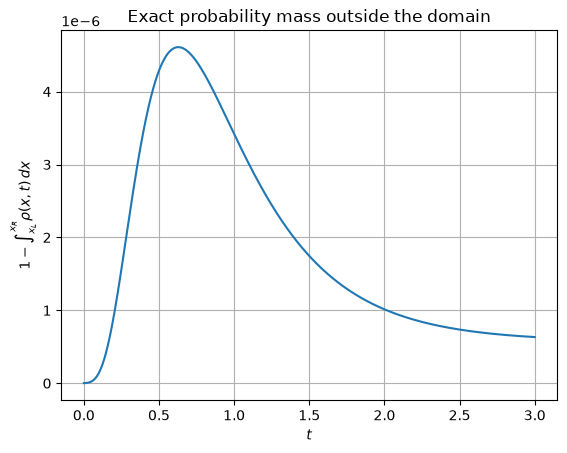

In [12]:
plt.figure()

plt.plot(tail_times,outside_mass_history)

plt.xlabel(r"$t$")
plt.ylabel(
    r"$1-\int_{x_L}^{x_R}\rho(x,t)\,dx$"
)

plt.title("Exact probability mass outside the domain")
plt.grid()
plt.show()

### Performances for different truncated domains

In [13]:
domains = [
    (-3.0, 3.0),
    (-4.0, 4.0),
    (-5.0, 5.0),
    (-6.0, 6.0)
]

print(
    f"{'Domain':>16} "
    f"{'Maximum outside mass':>24} "
    f"{'Percentage':>16}"
)

for left, right in domains:

    outside_values = np.array([
        exact_mass_outside(t,left,right,k,D,m0,s0)
        for t in tail_times
    ])

    maximum_tail = np.max(outside_values)

    print(
        f"[{left:4.1f}, {right:4.1f}] "
        f"{maximum_tail:24.8e} "
        f"{100 * maximum_tail:15.8e}%"
    )

          Domain     Maximum outside mass       Percentage
[-3.0,  3.0]           2.77554373e-02  2.77554373e+00%
[-4.0,  4.0]           5.45417109e-04  5.45417109e-02%
[-5.0,  5.0]           4.60978582e-06  4.60978582e-04%
[-6.0,  6.0]           1.53192014e-08  1.53192014e-06%


### Trajectory of the density

In [14]:
# ============================================================
# Generate FD density snapshots using ou_fd.py
# ============================================================

fd_plot_times = np.array([
    0.0,
    0.5,
    1.0,
    2.0,
    3.0,
])

fd_solution = solve_ou_fd(
    Nx=200,
    Nt=96000,
    save_times=fd_plot_times,
    track_history=True,
    **ou_parameters,
)

# Keep these short names because the later Week 1 plotting and comparison
# cells already use them.
x = fd_solution["x"]
snapshots = fd_solution["snapshots"]

print("FD spatial shape:   ", x.shape)
print("FD internal dt:     ", fd_solution["dt"])
print("FD saved times:     ", sorted(snapshots.keys()))


FD spatial shape:    (201,)
FD internal dt:      3.125e-05
FD saved times:      [0.0, 0.5, 1.0, 2.0, 3.0]


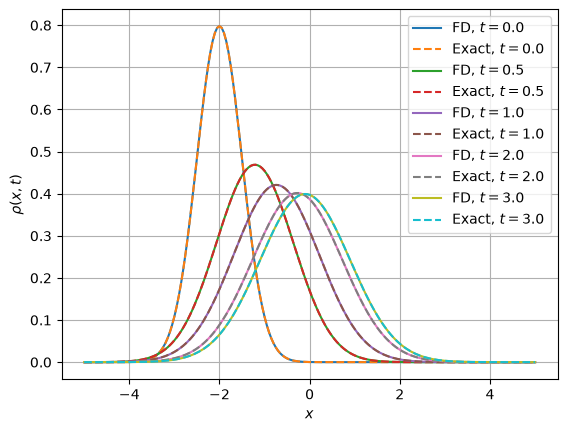

In [15]:
plt.figure()

for t, rho_num in sorted(snapshots.items()):

    rho_exact = exact_ou_density(x, t, k, D, m0, s0)

    plt.plot(x,rho_num,label=fr"FD, $t={t}$")

    plt.plot(x,rho_exact,"--",label=fr"Exact, $t={t}$")

plt.xlabel(r"$x$")
plt.ylabel(r"$\rho(x,t)$")
plt.legend()
plt.grid()
plt.show()

### Euler-Maruyama 

In [16]:
k = 1
D = 1

x_L = -5
x_R = 5
m0 = -2.0
s0 = 0.5
T=3

In [17]:
# ============================================================
# Import the reusable Euler-Maruyama solver
# ============================================================

import ou_em

# Reload after editing ou_em.py without restarting the kernel.
importlib.reload(ou_em)

solve_ou_em = ou_em.solve_ou_em


In [18]:
# FD and EM solve the same OU model, so both use ou_parameters.
ou_em_parameters = ou_parameters.copy()


In [19]:
# The Euler-Maruyama update, particle simulation and histogram construction
# are now implemented in ou_em_week1.py rather than duplicated here.


In [20]:
# ============================================================
# Run the reusable Euler-Maruyama solver
# ============================================================

num_paths = 60000
N_em = 6000

# Sparse times used for Week 1 plots and statistical validation.
save_times_em = np.array([
    0.0,
    0.5,
    1.0,
    2.0,
    3.0,
])

# Match the existing FD density grid.
Nx_em = len(x) - 1

em_solution = solve_ou_em(
    num_paths=num_paths,
    N_em=N_em,
    Nx=Nx_em,
    save_times=save_times_em,
    seed=319,

    # Required in Week 1 because the estimation cells use the
    # particle samples to compute moments and subsampling errors.
    store_particles=True,

    **ou_em_parameters,
)

x_em = em_solution["x"]
dt_em = em_solution["dt_em"]

# Density snapshots for plots and density-error estimation.
em_density_snapshots = em_solution["snapshots"]

# Particle snapshots for sample moments and MC convergence.
em_snapshots = em_solution["particle_snapshots"]

bin_edges = em_solution["bin_edges"]
bin_widths = em_solution["bin_widths"]
bin_centres = em_solution["bin_centres"]
inside_mass = em_solution["inside_mass"]

print("EM spatial grid shape:   ", x_em.shape)
print("EM time step:            ", dt_em)
print("Saved times:             ", em_solution["times"])
print("Density snapshot shape:  ", em_density_snapshots[0.0].shape)
print("Particle snapshot shape: ", em_snapshots[0.0].shape)


EM spatial grid shape:    (201,)
EM time step:             0.0005
Saved times:              [0.  0.5 1.  2.  3. ]
Density snapshot shape:   (201,)
Particle snapshot shape:  (60000,)


In [21]:
def exact_ou_moments(t, k, D, m0, s0):

    mean = m0 * np.exp(-k * t)

    variance = (
        s0**2 * np.exp(-2 * k * t)
        + D / k * (1 - np.exp(-2 * k * t))
    )

    return mean, variance

def em_ou_moments(t, dt, k, D, m0, s0):

    n = int(round(t / dt))

    a = 1 - k * dt

    mean = a**n * m0

    if np.isclose(1 - a**2, 0.0):

        noise_variance = 2 * D * dt * n

    else:

        noise_variance = (
            2 * D * dt
            * (1 - a**(2 * n))
            / (1 - a**2)
        )

    variance = (
        a**(2 * n) * s0**2
        + noise_variance
    )

    return mean, variance

def gaussian_bin_density(bin_edges, mean, variance):

    standard_deviation = np.sqrt(variance)

    z_edges = (
        bin_edges - mean
    ) / standard_deviation

    bin_probabilities = np.diff(
        ndtr(z_edges)
    )

    bin_widths = np.diff(bin_edges)

    return bin_probabilities / bin_widths

def histogram_errors(
    rho_numerical,
    rho_reference,
    bin_widths
):

    error = rho_numerical - rho_reference

    L1 = np.sum(
        bin_widths * np.abs(error)
    )

    L2 = np.sqrt(
        np.sum(
            bin_widths * error**2
        )
    )

    Linf = np.max(
        np.abs(error)
    )

    return L1, L2, Linf

In [22]:
# ============================================================
# Check the returned FD and EM data
# ============================================================
if x_em.shape != x.shape or not np.allclose(x_em, x):
    raise ValueError(
        "The EM and FD density grids do not agree. "
        "Use the same Nx, x_L and x_R in both solvers."
    )

for t in save_times_em:

    if t not in snapshots:
        raise KeyError(
            f"FD density snapshot at t={t} was not returned."
        )

    if t not in em_density_snapshots:
        raise KeyError(
            f"EM density snapshot at t={t} was not returned."
        )

    if t not in em_snapshots:
        raise KeyError(
            f"EM particle snapshot at t={t} was not returned. "
            "Call solve_ou_em with store_particles=True."
        )

In [23]:
inside_mass_table = pd.DataFrame({
    "t": em_solution["times"],
    "Mass inside histogram window": [
        inside_mass[t]
        for t in em_solution["times"]
    ],
})

display(
    inside_mass_table.style
    .hide(axis="index")
    .format({
        "t": "{:.1f}",
        "Mass inside histogram window": "{:.10f}",
    })
    .set_caption(
        "Observed Monte Carlo mass inside the histogram window"
    )
)


t,Mass inside histogram window
0.0,1.0000000000
0.5,1.0000000000
1.0,0.9999833333
2.0,1.0000000000
3.0,1.0000000000


In [24]:
import numpy as np
import pandas as pd
from IPython.display import display


# ======================================================
# Validation times
# ======================================================

comparison_times = [0.0, 0.5, 1.0, 2.0, 3.0]

results = []


# ======================================================
# Compute validation results
# ======================================================

for t in comparison_times:

    samples = em_snapshots[t]
    rho_hist = em_density_snapshots[t]

    number_of_samples = len(samples)

    # --------------------------------------------------
    # Exact continuous-time OU moments
    # --------------------------------------------------

    exact_mean, exact_variance = exact_ou_moments(
        t,
        k,
        D,
        m0,
        s0
    )

    # --------------------------------------------------
    # Theoretical moments of the discrete EM process
    # --------------------------------------------------

    em_mean, em_variance = em_ou_moments(
        t,
        dt_em,
        k,
        D,
        m0,
        s0
    )

    # --------------------------------------------------
    # Bin-averaged theoretical densities
    # --------------------------------------------------

    rho_exact_bins = gaussian_bin_density(
        bin_edges,
        exact_mean,
        exact_variance
    )

    rho_em_theory_bins = gaussian_bin_density(
        bin_edges,
        em_mean,
        em_variance
    )

    # --------------------------------------------------
    # Monte Carlo sample moments
    # --------------------------------------------------

    sample_mean = np.mean(samples)

    sample_variance = np.var(
        samples,
        ddof=1
    )

    # --------------------------------------------------
    # Histogram-window check
    # --------------------------------------------------

    x_left = bin_edges[0]
    x_right = bin_edges[-1]

    outside_mask = (
        (samples < x_left)
        |
        (samples > x_right)
    )

    # Observed number of samples outside the window
    sample_outside_count = np.count_nonzero(
        outside_mask
    )

    # Observed outside probability
    sample_outside_fraction = (
        sample_outside_count
        /
        number_of_samples
    )

    # Theoretical probability mass inside the window
    em_window_mass = np.sum(
        bin_widths * rho_em_theory_bins
    )

    exact_window_mass = np.sum(
        bin_widths * rho_exact_bins
    )

    # Theoretical probability mass outside the window
    # max prevents tiny negative values caused by rounding
    em_outside_fraction = max(
        0.0,
        1.0 - em_window_mass
    )

    exact_outside_fraction = max(
        0.0,
        1.0 - exact_window_mass
    )

    # Expected number of EM samples outside the window
    expected_outside_count = (
        number_of_samples
        *
        em_outside_fraction
    )

    # --------------------------------------------------
    # Monte Carlo / histogram error
    #
    # Histogram density versus theoretical EM density
    # --------------------------------------------------

    mc_L1, mc_L2, mc_Linf = histogram_errors(
        rho_hist,
        rho_em_theory_bins,
        bin_widths
    )

    # --------------------------------------------------
    # EM time-discretisation error
    #
    # Theoretical EM density versus exact OU density
    # --------------------------------------------------

    time_L1, time_L2, time_Linf = histogram_errors(
        rho_em_theory_bins,
        rho_exact_bins,
        bin_widths
    )

    # --------------------------------------------------
    # Total observed error
    #
    # Histogram density versus exact OU density
    # --------------------------------------------------

    total_L1, total_L2, total_Linf = histogram_errors(
        rho_hist,
        rho_exact_bins,
        bin_widths
    )

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    results.append({
        "t": t,

        "Number of samples": number_of_samples,

        "Sample mean": sample_mean,
        "EM mean": em_mean,
        "Exact mean": exact_mean,

        "Sample variance": sample_variance,
        "EM variance": em_variance,
        "Exact variance": exact_variance,

        "Outside count": sample_outside_count,
        "Expected outside count": expected_outside_count,

        "Sample outside": sample_outside_fraction,
        "EM outside": em_outside_fraction,
        "Exact outside": exact_outside_fraction,

        "MC L1": mc_L1,
        "EM time L1": time_L1,
        "Total L1": total_L1,

        "MC L2": mc_L2,
        "EM time L2": time_L2,
        "Total L2": total_L2,

        "MC Linf": mc_Linf,
        "EM time Linf": time_Linf,
        "Total Linf": total_Linf
    })


# Convert results to a DataFrame
results_df = pd.DataFrame(results)


# ======================================================
# Common table style
# ======================================================

def style_validation_table(styler, caption):

    table_styles = [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "8px 0 35px 0"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "14px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "left"),
                ("font-size", "19px"),
                ("font-weight", "bold"),
                ("padding", "8px 0 12px 0")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#e9ecef"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "9px 13px"),
                ("border", "1px solid #adb5bd"),
                ("white-space", "nowrap")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 13px"),
                ("border", "1px solid #ced4da"),
                ("white-space", "nowrap")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#f8f9fa")
            ]
        },
        {
            "selector": "tbody tr:hover",
            "props": [
                ("background-color", "#e7f1ff")
            ]
        }
    ]

    return (
        styler
        .hide(axis="index")
        .set_caption(caption)
        .set_table_styles(table_styles)
    )


# ======================================================
# Table 1: moment comparison
# ======================================================

moments_table = results_df[
    [
        "t",
        "Sample mean",
        "EM mean",
        "Exact mean",
        "Sample variance",
        "EM variance",
        "Exact variance"
    ]
].copy()

moments_table.columns = pd.MultiIndex.from_tuples([
    ("Time", "t"),

    ("Mean", "Sample"),
    ("Mean", "EM theory"),
    ("Mean", "Exact"),

    ("Variance", "Sample"),
    ("Variance", "EM theory"),
    ("Variance", "Exact")
])

moments_styler = moments_table.style.format({
    ("Time", "t"): "{:.1f}",

    ("Mean", "Sample"): "{:.8f}",
    ("Mean", "EM theory"): "{:.8f}",
    ("Mean", "Exact"): "{:.8f}",

    ("Variance", "Sample"): "{:.8f}",
    ("Variance", "EM theory"): "{:.8f}",
    ("Variance", "Exact"): "{:.8f}"
})

display(
    style_validation_table(
        moments_styler,
        "Table 1. Moment comparison"
    )
)


# ======================================================
# Table 2: histogram-window adequacy
# ======================================================

window_table = results_df[
    [
        "t",
        "Number of samples",
        "Outside count",
        "Expected outside count",
        "Sample outside",
        "EM outside",
        "Exact outside"
    ]
].copy()

window_table.columns = pd.MultiIndex.from_tuples([
    ("Time", "t"),

    ("Monte Carlo", "Samples"),

    ("Outside samples", "Observed"),
    ("Outside samples", "Expected"),

    ("Outside probability", "Sample"),
    ("Outside probability", "EM theory"),
    ("Outside probability", "Exact")
])

window_styler = window_table.style.format({
    ("Time", "t"): "{:.1f}",

    ("Monte Carlo", "Samples"): "{:.0f}",

    ("Outside samples", "Observed"): "{:.0f}",
    ("Outside samples", "Expected"): "{:.4f}",

    ("Outside probability", "Sample"): "{:.6e}",
    ("Outside probability", "EM theory"): "{:.6e}",
    ("Outside probability", "Exact"): "{:.6e}"
})

display(
    style_validation_table(
        window_styler,
        "Table 2. Histogram-window adequacy check"
    )
)


# ======================================================
# Table 3: density errors
# ======================================================

errors_table = results_df[
    [
        "t",

        "MC L1",
        "EM time L1",
        "Total L1",

        "MC L2",
        "EM time L2",
        "Total L2",

        "MC Linf",
        "EM time Linf",
        "Total Linf"
    ]
].copy()

errors_table.columns = pd.MultiIndex.from_tuples([
    ("Time", "t"),

    ("L1 error", "Monte Carlo"),
    ("L1 error", "EM time"),
    ("L1 error", "Total"),

    ("L2 error", "Monte Carlo"),
    ("L2 error", "EM time"),
    ("L2 error", "Total"),

    ("Linf error", "Monte Carlo"),
    ("Linf error", "EM time"),
    ("Linf error", "Total")
])

errors_styler = errors_table.style.format({
    ("Time", "t"): "{:.1f}",

    ("L1 error", "Monte Carlo"): "{:.6e}",
    ("L1 error", "EM time"): "{:.6e}",
    ("L1 error", "Total"): "{:.6e}",

    ("L2 error", "Monte Carlo"): "{:.6e}",
    ("L2 error", "EM time"): "{:.6e}",
    ("L2 error", "Total"): "{:.6e}",

    ("Linf error", "Monte Carlo"): "{:.6e}",
    ("Linf error", "EM time"): "{:.6e}",
    ("Linf error", "Total"): "{:.6e}"
})

display(
    style_validation_table(
        errors_styler,
        "Table 3. Density approximation errors"
    )
)

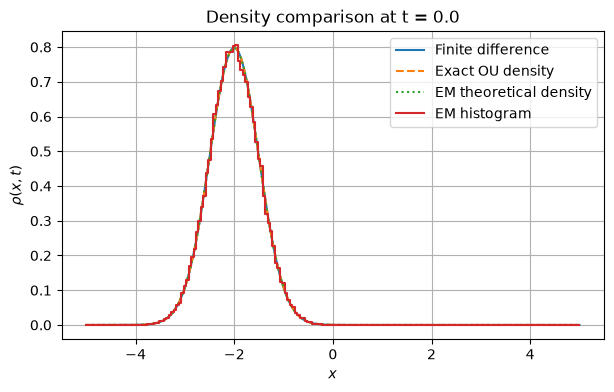

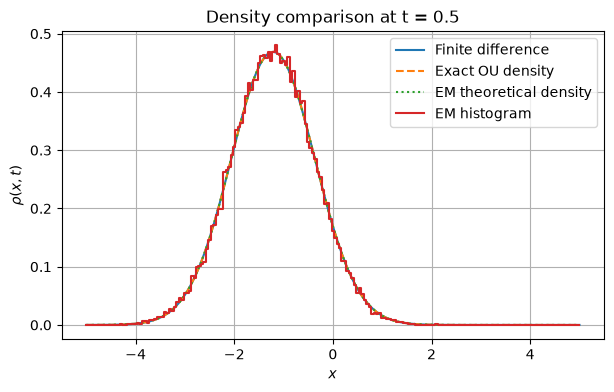

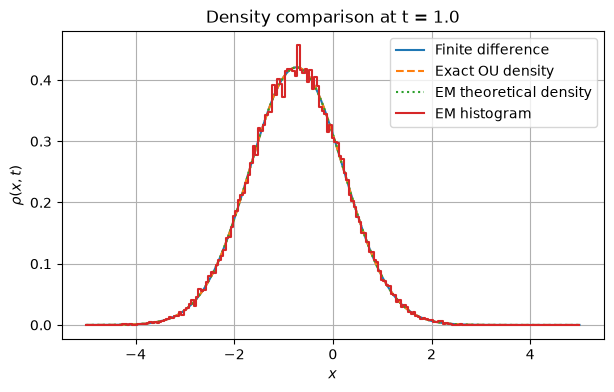

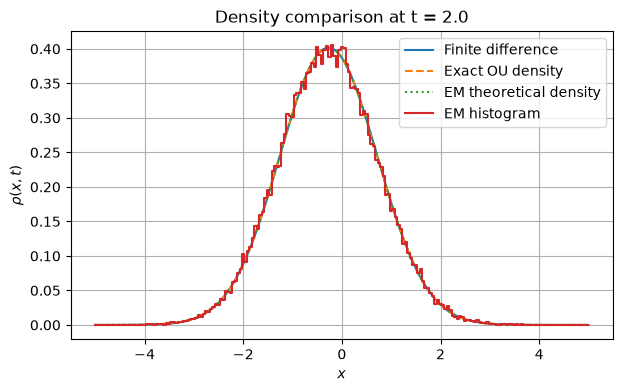

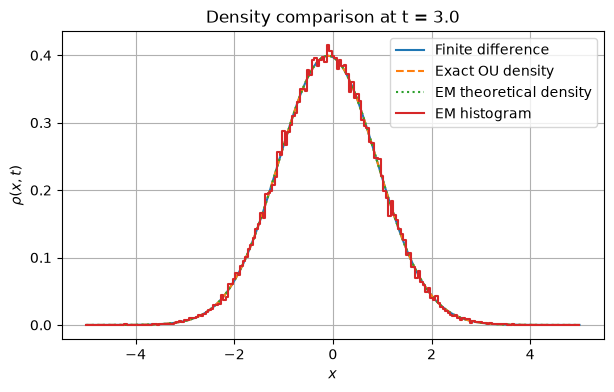

In [25]:
for t in comparison_times:

    rho_fd = snapshots[t]
    rho_hist = em_density_snapshots[t]

    rho_exact = exact_ou_density(
        x_em,
        t,
        k,
        D,
        m0,
        s0
    )

    em_mean, em_variance = em_ou_moments(
        t,
        dt_em,
        k,
        D,
        m0,
        s0
    )

    rho_em_theory = (
        np.exp(
            -0.5
            * (x_em - em_mean)**2
            / em_variance
        )
        /
        np.sqrt(
            2 * np.pi * em_variance
        )
    )

    plt.figure(figsize=(7, 4))

    plt.plot(
        x,
        rho_fd,
        label="Finite difference"
    )

    plt.plot(
        x_em,
        rho_exact,
        "--",
        label="Exact OU density"
    )

    plt.plot(
        x_em,
        rho_em_theory,
        ":",
        label="EM theoretical density"
    )

    plt.step(
        bin_centres,
        rho_hist,
        where="mid",
        label="EM histogram"
    )

    plt.xlabel(r"$x$")
    plt.ylabel(r"$\rho(x,t)$")
    plt.title(f"Density comparison at t = {t}")
    plt.legend()
    plt.grid()
    plt.show()


Samples,Mean_L1,Std_L1,Q90_Max_L1,Mean_L2,Std_L2,Mean_Linf,Std_Linf
1000,2.254397e-01,6.877238e-03,2.687840e-01,1.378958e-01,5.620728e-03,2.149335e-01,2.037545e-02
2000,1.603905e-01,4.655772e-03,1.917830e-01,9.798832e-02,3.345596e-03,1.517541e-01,1.260103e-02
5000,1.031807e-01,2.306002e-03,1.267771e-01,6.235042e-02,2.163742e-03,9.607582e-02,7.745634e-03
10000,7.258368e-02,2.445060e-03,8.934882e-02,4.414556e-02,1.851541e-03,6.832963e-02,6.072044e-03
20000,5.086843e-02,1.757916e-03,6.124646e-02,3.087651e-02,1.289507e-03,4.888952e-02,4.258049e-03
40000,3.645300e-02,8.418777e-04,4.287714e-02,2.218363e-02,6.130193e-04,3.436127e-02,3.237636e-03
60000,2.950041e-02,0.000000e+00,3.212217e-02,1.790367e-02,0.000000e+00,2.685689e-02,0.000000e+00


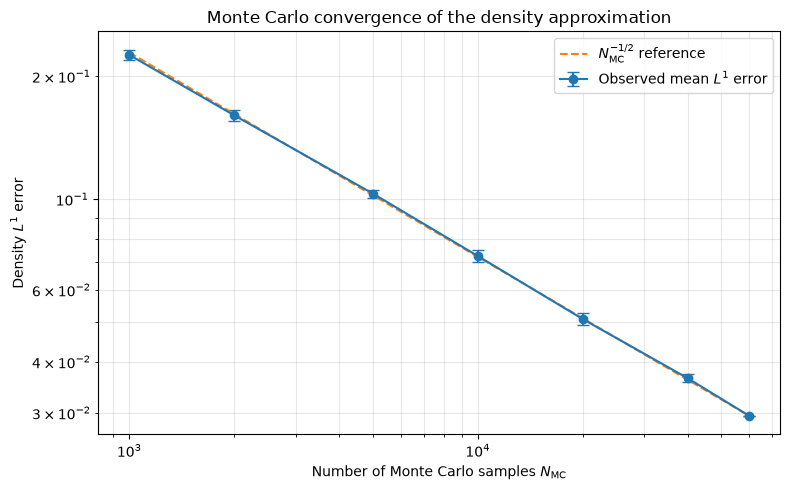

In [26]:
# ============================================================
# Monte Carlo ensemble-size convergence test
# ============================================================

sample_sizes = np.array([
    1000,
    2000,
    5000,
    10000,
    20000,
    40000,
    60000
])

number_of_repeats = 20
rng = np.random.default_rng(2026)

available_samples = min(
    len(em_snapshots[t])
    for t in comparison_times
)

sample_sizes = sample_sizes[
    sample_sizes <= available_samples
]

mc_convergence_results = []


for repeat in range(number_of_repeats):

    # One common permutation is used at every time.
    # This preserves the same particle labels across time.
    permutation = rng.permutation(available_samples)

    for number_of_samples in sample_sizes:

        sample_indices = permutation[:number_of_samples]

        L1_errors = []
        L2_errors = []
        Linf_errors = []

        for t in comparison_times:

            samples = np.asarray(
                em_snapshots[t]
            )[sample_indices]

            # Histogram counts
            counts, _ = np.histogram(
                samples,
                bins=bin_edges
            )

            # Divide by the total number of samples,
            # rather than using density=True.
            # This preserves any mass outside the window.
            rho_hist = (
                counts
                /
                (
                    number_of_samples
                    * bin_widths
                )
            )

            # Theoretical density of the discrete EM process
            em_mean, em_variance = em_ou_moments(
                t,
                dt_em,
                k,
                D,
                m0,
                s0
            )

            rho_em_theory = gaussian_bin_density(
                bin_edges,
                em_mean,
                em_variance
            )

            L1_error, L2_error, Linf_error = histogram_errors(
                rho_hist,
                rho_em_theory,
                bin_widths
            )

            L1_errors.append(L1_error)
            L2_errors.append(L2_error)
            Linf_errors.append(Linf_error)

        mc_convergence_results.append({
            "Repeat": repeat,
            "Samples": number_of_samples,

            "Mean L1": np.mean(L1_errors),
            "Maximum L1": np.max(L1_errors),

            "Mean L2": np.mean(L2_errors),
            "Maximum L2": np.max(L2_errors),

            "Mean Linf": np.mean(Linf_errors),
            "Maximum Linf": np.max(Linf_errors)
        })


mc_convergence_df = pd.DataFrame(
    mc_convergence_results
)


# ============================================================
# Summarise repeated subsampling experiments
# ============================================================

mc_convergence_summary = (
    mc_convergence_df
    .groupby("Samples")
    .agg(
        Mean_L1=("Mean L1", "mean"),
        Std_L1=("Mean L1", "std"),
        Q90_Max_L1=(
            "Maximum L1",
            lambda values: values.quantile(0.90)
        ),

        Mean_L2=("Mean L2", "mean"),
        Std_L2=("Mean L2", "std"),

        Mean_Linf=("Mean Linf", "mean"),
        Std_Linf=("Mean Linf", "std")
    )
    .reset_index()
)

display(
    mc_convergence_summary.style
    .hide(axis="index")
    .format({
        "Samples": "{:d}",
        "Mean_L1": "{:.6e}",
        "Std_L1": "{:.6e}",
        "Q90_Max_L1": "{:.6e}",
        "Mean_L2": "{:.6e}",
        "Std_L2": "{:.6e}",
        "Mean_Linf": "{:.6e}",
        "Std_Linf": "{:.6e}"
    })
    .set_caption(
        "Monte Carlo ensemble-size convergence"
    )
)


# ============================================================
# Log-log convergence plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    mc_convergence_summary["Samples"],
    mc_convergence_summary["Mean_L1"],
    yerr=mc_convergence_summary["Std_L1"],
    marker="o",
    capsize=4,
    label=r"Observed mean $L^1$ error"
)

# N^{-1/2} reference line, anchored at the largest sample size
N_reference = mc_convergence_summary["Samples"].to_numpy()

error_at_largest_N = (
    mc_convergence_summary["Mean_L1"]
    .iloc[-1]
)

reference_error = (
    error_at_largest_N
    *
    np.sqrt(
        N_reference[-1]
        /
        N_reference
    )
)

ax.plot(
    N_reference,
    reference_error,
    "--",
    label=r"$N_{\mathrm{MC}}^{-1/2}$ reference"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Number of Monte Carlo samples $N_{\mathrm{MC}}$"
)
ax.set_ylabel(
    r"Density $L^1$ error"
)

ax.set_title(
    "Monte Carlo convergence of the density approximation"
)

ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Conclusion

The finite-difference solver reproduces the exact Ornstein–Uhlenbeck density
and exhibits approximately second-order convergence under the coupled
refinement $\Delta t\propto\Delta x^2$. Since Forward Euler is first order in
time, this experiment measures the combined error under this refinement
strategy rather than an independent second-order temporal rate.

On the domain $[-5,5]$, the maximum exact probability mass outside the
computational interval over $t\in[0,3]$ is approximately
$4.61\times10^{-6}$. Domain truncation is therefore negligible at the
resolutions used in the later experiments.

The Euler–Maruyama validation separates time-discretisation error from
Monte Carlo and histogram errors. The repeated subsampling experiment is
consistent with the expected $N_{\mathrm{MC}}^{-1/2}$ sampling behaviour.

These checks validate the exact, finite-difference, and trajectory-based
density sources used in the subsequent SINDy experiments.